# Particle in a Box 1D
## Computational Implementation
course: SOLST01 AY2025-2026 T3
lecture: Computational Particle in a Box
author: Eugene Joseph M. Ragasa

## Purpose

You have already seen the particle-in-a-box problem several times. At this point, the main purpose is not to introduce a new quantum system. The purpose of this lecture is to use a familiar problem to introduce the computational techniques we will use throughout the course.

The analytical problem is

$$
\hat{H}|\psi_n\rangle
=
E_n|\psi_n\rangle.
$$

In this notebook, we represent the same problem as a matrix eigenvalue problem:

$$
H\boldsymbol{\psi}_n
=
E_n\boldsymbol{\psi}_n.
$$

The transition is:

```mermaid
flowchart LR
    A["Hamiltonian operator"] --> B["Hamiltonian matrix"]
    C["Continuous wavefunction"] --> D["Grid vector"]
    E["Differential equation"] --> F["Matrix eigenvalue problem"]
```

In equations, this means

$$\begin{gather}
\hat{H} 
  \longrightarrow
  H \\
\psi(x)
  \longrightarrow
  \boldsymbol{\psi},\\
\hat{H}|\psi_n\rangle 
  = E_n|\psi_n\rangle
  \longrightarrow
    H\boldsymbol{\psi}_n
    = E_n\boldsymbol{\psi}_n.
\end{gather}$$

Your previous quantum mechanics course should have introduced states such as

$$
|\psi\rangle \in \mathcal{H}.
$$

Here, $\mathcal{H}$ is a Hilbert space: a vector space equipped with an inner product. The useful idea is that many operations familiar from finite-dimensional linear algebra—basis expansions, projections, orthogonality, eigenvectors, and eigenvalues—also apply to wavefunctions. The full mathematical theory belongs to functional analysis, but in this course we will use Dirac notation and matrix computation to keep the structure explicit.

We will use Python because it is widely used for scientific analysis, has strong numerical libraries, and allows us to focus on the physics rather than low-level numerical implementation. This is not a numerical analysis course; we will use standard tools to build and inspect the quantum operators.

Finally, Python notebooks are accessible. If you have difficulty setting up Python locally, you may use Google Colab instead. You can create a Colab notebook, complete the work there, and submit the resulting `.ipynb` file.

If you have difficulty setting up Python locally, you may use Google Colab. You can create a Colab notebook, complete the work there, and submit the resulting .ipynb file.

## Programming and Generative AI Policy

Many of you are still new to programming. It is acceptable, and expected, that some students will use generative AI tools to help write, debug, or understand code.

However, you are responsible for any code you submit. You should be able to explain what your code does, why it works, and how it relates to the mathematical model discussed in class.

You are expected to follow coding conventions similar to those used in this notebook. In particular, your code should be readable, organized, and written at a level that you can personally explain. If your submitted code uses techniques that are far beyond what we have discussed, I may ask you to explain the code in detail.

Failure to explain submitted code may affect your grade, even if the code runs correctly.  If it takes me forever to follow your code, I will not grade it.

### Alternative programming languages
If you prefer to work in a programming language other than Python, speak with me ahead of time. I will try to accommodate reasonable alternatives. If you use MATLAB, your code must also run in GNU Octave. I will not require or purchase a proprietary MATLAB license for this course.

Part of the reason we use Python is that it provides a free, open, and widely supported environment for scientific computing. This makes it easier for every student to run, modify, and submit computational work without depending on proprietary software.

### Import Libraries
The beginning of any python script start with the import of libraries.  We will be using standard numerical libraries in python for which there are plenty of references online.  


- `numpy` is used to create arrays, grid points, diagonal matrices, and the like
- `scipy.linalg` provides matrix eigensolvers,  we will use it to solve the Hamiltonian eigenvalue problem.
- `matplotlib.pyplot` is a plotting library

In [12]:
import numpy as np                # linear algebra libraries
import scipy.linalg               # more linalg algebra libraries
import matplotlib.pyplot as plt   # plotting libraries

### Define the Domain and the Grid
The analytical particle in a particle is defined on the open integral
$$
0 < x L
$$
The hard-wall boundary conditions are
$$\begin{align}
\psi(0)=0
\end{align}$$
For the computational problem, we first create a grid on the closed interval
$$
x_{\min}\leq x\leq x_{\max},
$$
where
$$
x_{\min}=0,
\qquad
x_{\max}=x_{\min}+L.
$$

The grid includes the boundary points, but the wavefunction values at the boundaries are already known. They are fixed to zero. Therefore, the unknown wavefunction values live only on the interior grid points.

In [13]:
# In this notebook, we use dimensionless units.  To remove the unit 
# conversion clutter and focus on the operator structure.  Once the
# method is understood, physical units can be introduced.  While SI units
# are a typical route, alternate unit systems are common in solid state, such
# as eV for energy and Angstrom for lengh

# physical parameters
hbar: float = 1.      # planck's constant, n.d.
m: float = 1.         # weight of the particle, n.d.
L: float = 1.         # length of the well, n.d.

# define the domain
x_min: float = 0.
x_max: float = x_min + L
N_x: int = 10

## Visualize the Grid

The full grid includes both boundary points and interior points.

$$\begin{align}
\mathbf{x} 
&=
\begin{bmatrix}
  x_1 & x_2 & \cdots & x_{N_x}
\end{bmatrix}
\\
\boldsymbol{\psi(x)}
&=
\begin{bmatrix}
  \psi(x_1) & \psi(x_2) & \cdots & \psi(x_{N_x})
\end{bmatrix}^\mathsf{T}
\\
\boldsymbol{\psi}
&=
\begin{bmatrix}
  \psi_1 & \psi_2 & \cdots & \psi_{N_x}
\end{bmatrix}^\mathsf{T}
\end{align}$$

The boundary points are fixed by the hard-wall conditions:

$$
\psi(x_{\min})=0,
\qquad
\psi(x_{\max})=0.
$$

The interior points are where the unknown wavefunction values live. These are the values stored in the computational vector



x
   [0.     0.1111 0.2222 0.3333 0.4444 0.5556 0.6667 0.7778 0.8889 1.    ]
  .shape: (10,)
  .Nx 10
x_interior
   [0.1111 0.2222 0.3333 0.4444 0.5556 0.6667 0.7778 0.8889]
  .shape (8,)
  .Nx: 8


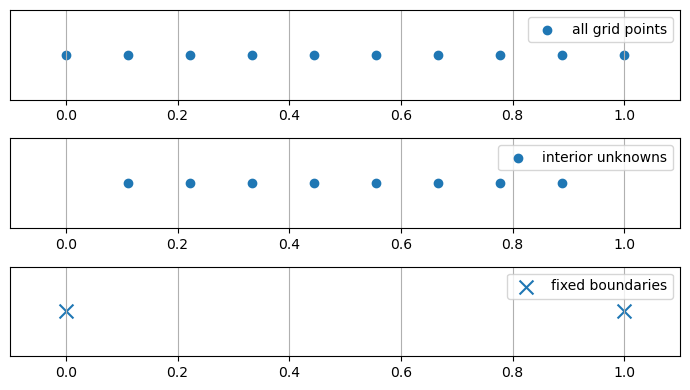

In [14]:
x = np.linspace(x_min, x_max, 10)
Nx = x.shape[0]
with np.printoptions(precision=4, suppress=True):
    print("x")
    print("  ",x)
    print("  .shape:",x.shape)
    print("  .Nx",Nx)

x_interior = x[1:-1]
Nx_interior = x_interior.shape[0]
with np.printoptions(precision=4, suppress=True):
    print("x_interior")
    print("  ",x_interior)
    print("  .shape",x_interior.shape)
    print("  .Nx:",Nx_interior)

dx = x[1]-x[0]

fig, ax = plt.subplots(nrows=3,ncols=1)
fig.set_size_inches(7,4)

ax[0].scatter(
    x,
    np.zeros_like(x),
    label="all grid points",
)

ax[1].scatter(
    x_interior,
    np.zeros_like(x_interior),
    label="interior unknowns",
)

ax[2].scatter(
    [x_min, x_max],
    [0, 0],
    marker="x",
    s=100,
    label="fixed boundaries",
)

for a in ax:
  a.set_xlim([-.1,1.1])
  a.set_yticks([])
  a.legend()
  a.grid(True)

fig.tight_layout()


## Finite-Difference Approximation
The kinetic operator is
$$\begin{gather}
  \hat{T}
    =-\frac{\hbar^2}{2m}\nabla^2 \\
  \langle x |\hat{T}| \psi \rangle 
    = -\frac{\hbar^2}{2m}
      \langle x | \nabla^2 | \psi \rangle 
\end{gather}$$
For $\langle x | \psi \rangle$ 1D,
$$
  \langle x | \nabla^2 | \psi \rangle 
    = \frac{\mathrm{d}^2}{\mathrm{d}x^2}\psi(x)
$$
How do we approximate this derivative when
$$\begin{align}
  \mathrm{x}
    &=  \begin{bmatrix} 
          x_1 & x_2 & \cdots & x_N 
        \end{bmatrix}^\mathsf{T} \\
  \boldsymbol{\psi}
    &=  \begin{bmatrix}
          \psi_1 & \psi_2 & \cdots & \psi_{N}
        \end{bmatrix}^\mathsf{T}
\end{align}$$

Let us take the definition of the derivative from the left and right,
$$\begin{align}
  \frac{\mathrm{d}}{\mathrm{d}x}f(x)
    &= \lim_{h \to 0}
      \frac{f(x+h)-f(x)}{h} \\
    &\approx \frac{f(x+\Delta x)-f(x)}{\Delta x}\\
  \frac{\mathrm{d}}{\mathrm{d}x}f(x)
    &= \lim_{h \to 0}
      \frac{f(x)-f(x-h)}{h}\\
    &\approx \frac{f(x+\Delta x)-f(x)}{\Delta x}\\
\end{align}$$
Subsituting 
$$\begin{gather}
  f(x)=f_n\\ 
  f(x+\Delta x)=f_{n+1}\\
  f(x-\Delta x)=f_{n-1},
\end{gather}$$
we get
$$\begin{align}
  \frac{\mathrm{d}}{\mathrm{d}x}f_n
    &\approx \frac{f_{n+1}-f_n}{\Delta x}\\
  \frac{\mathrm{d}}{\mathrm{d}x}f_n
    &\approx \frac{f_{n}-f_{n-1}}{\Delta x}
\end{align}$$
At an interior grid point $x_i$, the second derivative is approximated by the centered finite difference

$$
\frac{\mathrm{d}^2}{\mathrm{d}x^2}(x_i)\psi
\approx
\frac{\psi(x_{i+1})
            - 2 \psi(x_i)
            + \psi(x_{i-1})}
     {\Delta x^2}.
$$
Using the notation
$$
\psi_i=\psi(x_i),
$$
this becomes

$$
\psi''(x_i)
\approx
\frac{
\psi_{i+1}
-
2\psi_i
+
\psi_{i-1}
}
{\Delta x^2}.
$$
This is a linear operation on the wavefunction values. Therefore, it can be written as a matrix acting on the vector
$$
\boldsymbol{\psi}
=
\begin{bmatrix}
\psi_1\\
\psi_2\\
\vdots\\
\psi_{N_{\mathrm{int}}}
\end{bmatrix}.
$$

In [15]:
# laplacian 1D
diag_main = -2.0 * np.ones(Nx_interior)
diag_off  =  1.0 * np.ones(Nx_interior-1)

with np.printoptions(precision=4, suppress=True):
    print("diag_main")
    print("  ", diag_main)
    print("  .shape",)
    
with np.printoptions(precision=4, suppress=True):
    print("diag_off")
    print("  ", diag_off)
    print("  .shape",)

# 2nd order finite difference matrix
lap1d_dirichlet = (
  np.diag(diag_main)
  + np.diag(diag_off, k=1)
  + np.diag(diag_off, k=-1)
)
print("lap1d_dirichlet:")
print(lap1d_dirichlet)

lap1d_dirichlet /= dx**2
print("lap1d_dirichlet:")
print(lap1d_dirichlet)


diag_main
   [-2. -2. -2. -2. -2. -2. -2. -2.]
  .shape
diag_off
   [1. 1. 1. 1. 1. 1. 1.]
  .shape
lap1d_dirichlet:
[[-2.  1.  0.  0.  0.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.  0.  0.  0.]
 [ 0.  1. -2.  1.  0.  0.  0.  0.]
 [ 0.  0.  1. -2.  1.  0.  0.  0.]
 [ 0.  0.  0.  1. -2.  1.  0.  0.]
 [ 0.  0.  0.  0.  1. -2.  1.  0.]
 [ 0.  0.  0.  0.  0.  1. -2.  1.]
 [ 0.  0.  0.  0.  0.  0.  1. -2.]]
lap1d_dirichlet:
[[-162.   81.    0.    0.    0.    0.    0.    0.]
 [  81. -162.   81.    0.    0.    0.    0.    0.]
 [   0.   81. -162.   81.    0.    0.    0.    0.]
 [   0.    0.   81. -162.   81.    0.    0.    0.]
 [   0.    0.    0.   81. -162.   81.    0.    0.]
 [   0.    0.    0.    0.   81. -162.   81.    0.]
 [   0.    0.    0.    0.    0.   81. -162.   81.]
 [   0.    0.    0.    0.    0.    0.   81. -162.]]


In [16]:
class BoundaryConditionType():
    Dirichlet=0

class LaplacianOperator1D():  
    @staticmethod
    def build_dirichlet(
            x:np.ndarray
        ) -> np.ndarray:
        x_interior: np.ndarray = x[1:-1]
        Nx_interior: int = x_interior.shape[0]
        dx = x[1]-x[0]

        diag_main = -2.0 * np.ones(Nx_interior)
        diag_off = 1.0 * np.ones(Nx_interior - 1)

        lap1d: np.ndarray = (
          np.diag(diag_main)
          + np.diag(diag_off, 1)
          + np.diag(diag_off, -1)
        ) / (dx**2)
        return lap1d

    @staticmethod
    def build(
            x:np.ndarray, 
            bc_type:BoundaryConditionType
        ) -> np.ndarray:
        if bc_type is BoundaryConditionType.Dirichlet:
            return LaplacianOperator1D.build_dirichlet(x=x)
        else:
            raise ValueError("unknown bc_type")
     

## Encapsulating the Laplacian Operator

We have now written the finite-difference form of the second derivative explicitly. For a single calculation, writing the matrix directly is acceptable. However, this course will reuse the same operators many times. If we rewrite the same matrix construction every time, the notebooks become harder to read and easier to break.

The better approach is to encapsulate the construction of the operator. Encapsulation means that we take a repeated piece of logic and give it a clear computational name. In this case, the mathematical object is the one-dimensional Laplacian operator, and the computational object is the matrix that represents it on a grid.

The important point is that the Laplacian matrix is not determined by the differential operator alone. It also depends on the grid and the boundary condition. A Dirichlet Laplacian, a periodic Laplacian, and a Bloch-periodic Laplacian are different matrices because they represent different physical constraints. The boundary condition is part of the definition of the operator.

For the particle in a box, we use Dirichlet boundary conditions. The wavefunction is fixed to zero at the endpoints, so only the interior grid points are unknown. The `LaplacianOperator1D` class below builds the corresponding finite-difference matrix using those interior points.

This is the coding pattern we will use throughout the course. We first identify the physical operator, then choose a representation, then build the corresponding matrix. The code should make this structure visible rather than hiding it.

In [19]:
lap1d_dirichlet_test = LaplacianOperator1D.build_dirichlet(
  x=x
)

print("lap1d_dirichlet")
print(lap1d_dirichlet)
print("\t.shape:",lap1d_dirichlet_test.shape)

print("lap1d_direchlet")
print(lap1d_dirichlet_test)
print("\t.shape:",lap1d_direchlet.shape)

print(np.allclose(lap1d_dirichlet,lap1d_dirichlet_test))
assert np.allclose(
    lap1d_dirichlet, 
    lap1d_dirichlet_test)

print(np.allclose(lap1d_dirichlet,lap1d_dirichlet_test))

# a more professional way to write tests
print(80*"-")
print("test_LaplaceOperator1D_build_direchlet")
print(
    np.allclose(
        lap1d_dirichlet,
        LaplacianOperator1D.build_dirichlet(x=x)
    )
)
assert np.allclose(
    lap1d_dirichlet,
    LaplacianOperator1D.build_dirichlet(x=x)
)

print(80*"-")
print("test_LaplaceOperator1D_build_w_bc_direchlet")
print(
    np.allclose(
        lap1d_dirichlet,
        lap1d_dirichlet_test
    )
)
assert np.allclose(
    lap1d_dirichlet,
    LaplacianOperator1D.build(
        x=x, 
        bc_type=BoundaryConditionType.Dirichlet
    )
)

lap1d_dirichlet
[[-162.   81.    0.    0.    0.    0.    0.    0.]
 [  81. -162.   81.    0.    0.    0.    0.    0.]
 [   0.   81. -162.   81.    0.    0.    0.    0.]
 [   0.    0.   81. -162.   81.    0.    0.    0.]
 [   0.    0.    0.   81. -162.   81.    0.    0.]
 [   0.    0.    0.    0.   81. -162.   81.    0.]
 [   0.    0.    0.    0.    0.   81. -162.   81.]
 [   0.    0.    0.    0.    0.    0.   81. -162.]]
	.shape: (8, 8)
lap1d_direchlet
[[-162.   81.    0.    0.    0.    0.    0.    0.]
 [  81. -162.   81.    0.    0.    0.    0.    0.]
 [   0.   81. -162.   81.    0.    0.    0.    0.]
 [   0.    0.   81. -162.   81.    0.    0.    0.]
 [   0.    0.    0.   81. -162.   81.    0.    0.]
 [   0.    0.    0.    0.   81. -162.   81.    0.]
 [   0.    0.    0.    0.    0.   81. -162.   81.]
 [   0.    0.    0.    0.    0.    0.   81. -162.]]
	.shape: (8, 8)
True
True
--------------------------------------------------------------------------------
test_LaplaceOperator1D_buil

In [22]:
def build_kinetic_matrix_1d(
    x,
    bc_type: BoundaryConditionType,
    hbar=1.,
    m=1.
) -> np.ndarray:
    
    lap1d: np.ndarray = LaplacianOperator1D.build(
        x=x,
        bc_type=bc_type
        )
    K_op:np.ndarray = -(hbar**2)/(2*m) * lap1d

    return K_op

K_op = build_kinetic_matrix_1d(
    x=x,
    bc_type=BoundaryConditionType.Dirichlet,
    hbar=hbar,
    m=m
)
print("K_op")
with np.printoptions(precision=4):
  print(K_op)

K_op
[[ 81.  -40.5  -0.   -0.   -0.   -0.   -0.   -0. ]
 [-40.5  81.  -40.5  -0.   -0.   -0.   -0.   -0. ]
 [ -0.  -40.5  81.  -40.5  -0.   -0.   -0.   -0. ]
 [ -0.   -0.  -40.5  81.  -40.5  -0.   -0.   -0. ]
 [ -0.   -0.   -0.  -40.5  81.  -40.5  -0.   -0. ]
 [ -0.   -0.   -0.   -0.  -40.5  81.  -40.5  -0. ]
 [ -0.   -0.   -0.   -0.   -0.  -40.5  81.  -40.5]
 [ -0.   -0.   -0.   -0.   -0.   -0.  -40.5  81. ]]


In [ ]:
def potential(
        x: np.ndarray,
        kwargs:dict=None
    ) -> np.ndarray:
    NotImplemented

def free_potential(x: np.ndarray, kwargs:dict=None) -> np.ndarray:
    return np.zeros_like(x)

def build_potential_matrix_1d(
        x: np.ndarray, 
        potential_func
        ) -> np.ndarray:
    x_interior = x[1:-1]
    V_x = potential_func(x_interior)
    return np.diag(V_x)

print(type(build_potential_matrix(x, free_potential)))
V_opt = build_potential_matrix(x, free_potential)

H_matrix = T_matrix + V_matrix

print(H_matrix)

In [ ]:
eigval, eigvec = scipy.linalg.eigh(H_matrix)

In [ ]:
print(eigval.shape)
print(eigvec.shape)

(8,)
(8, 8)


In [ ]:
class ParticleInABox1D():
    @staticmethod
    def get_laplacian_1d(Nx, dx):
      diag_main = -2.0 * np.ones(Nx)
      diag_off  =  1.0 * np.ones(Nx - 1)

      lap1D = (
          np.diag(diag_main)
          + np.diag(diag_off, k=1)
          + np.diag(diag_off, k=-1)
      ) / dx**2
      return lap1D

    def __init__(self,
      x_min, x_max, N_x,
      hbar=1., m=1., k=1.,
      V_func = free_potential
    ):
        self.hbar = hbar
        self.m = m
        self.k = k

        self.x_min: float = x_min
        self.x_max: float = x_max
        self.N_x: float = N_x

        self.V_func = V_func 
        self.x = np.linspace(self.x_min, self.x_max, self.N_x)

        self.T_op = None
        self.V_op = None
        self.H_op = None

        self.eigval: np.ndarray = None
        self.eigvec: np.ndarray = None

    @property
    def x_interior(self) -> np.ndarray:
        x_interior = self.x[1:-1]
        return x_interior
    
    @property
    def dx(self) -> float:
        dx = self.x[1] - self.x[0]
        return dx
    
    @property
    def kinetic_matrix(self) -> np.ndarray:
        N_interior = self.x_interior.size
        dx = self.dx
        hbar = self.hbar
        m = self.m

        D2_matrix = ParticleInABox1D.get_laplacian_1d(N_interior, dx)
        T_matrix = -(hbar**2/ (2.0 * m)) * D2_matrix
        return T_matrix
    
    @property
    def potential_matrix(self) -> np.ndarray:
        x_interior = self.x_interior
        V_array = self.V_func(x_interior)
        return np.diag(V_array)

    @property
    def hamiltonian_matrix(self) -> np.ndarray:
        T_op = self.kinetic_matrix
        V_op = self.potential_matrix
        H_op = T_op + V_op
        return H_op
    
    def solve(self):
        self.T_op = self.kinetic_matrix
        self.V_op = self.potential_matrix
        self.H_op = self.hamiltonian_matrix
        self.eigval, self.eigvec = scipy.linalg.eigh(self.H_op)

    

x_min = 0
x_max = 1
N_x = 100

piab1d = ParticleInABox1D(x_min, x_max, N_x)
piab1d.solve()

In [1]:
# plot eigenvalues
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional
piab1d.solve()

print(piab1d.eigval.shape)
print(piab1d.eigvec.shape)
exit()
# Solve first
def sort_eigenpairs(piab1d: ParticleInABox1D, 
                    N_states: Optional[int]=None):
    if N_states is None:
        N_states = piab1d.eigenvec

num_states = 10
n_array = np.arange(1, num_states + 1)
E_num = piab1d.eigval[:num_states]
L = piab1d.x_max - piab1d.x_min
hbar = piab1d.hbar
m = piab1d.m

E_exact = (
    n_array**2
    * np.pi**2
    * hbar**2
    / (2.0 * m * L**2)
)

plt.figure(figsize=(7, 5))

plt.scatter(n_array, E_num, label="numerical")
plt.plot(n_array, E_exact, marker="o", linestyle="--", label="analytical")

plt.xlabel("state index $n$")
plt.ylabel("energy $E_n$")
plt.title("Particle-in-a-Box Energy Eigenvalues")
plt.legend()
plt.grid(True)

plt.show()

NameError: name 'piab1d' is not defined

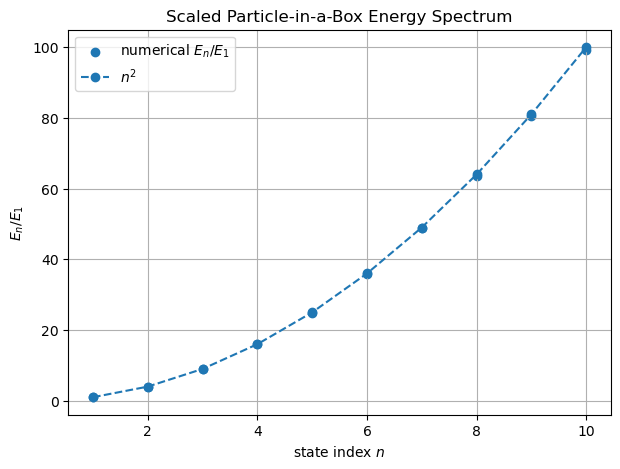

In [ ]:
E_num_scaled = E_num / E_num[0]
E_exact_scaled = n_array**2

plt.figure(figsize=(7, 5))

plt.scatter(n_array, E_num_scaled, label="numerical $E_n/E_1$")
plt.plot(n_array, E_exact_scaled, marker="o", linestyle="--", label="$n^2$")

plt.xlabel("state index $n$")
plt.ylabel("$E_n/E_1$")
plt.title("Scaled Particle-in-a-Box Energy Spectrum")
plt.legend()
plt.grid(True)

plt.show()

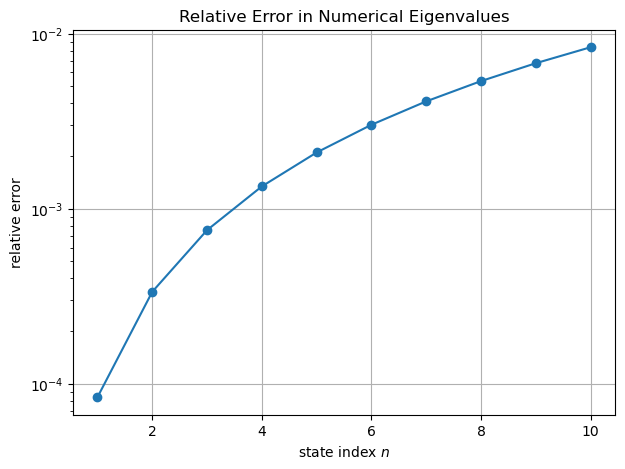

In [ ]:
relative_error = np.abs(E_num - E_exact) / E_exact

plt.figure(figsize=(7, 5))

plt.semilogy(n_array, relative_error, marker="o")

plt.xlabel("state index $n$")
plt.ylabel("relative error")
plt.title("Relative Error in Numerical Eigenvalues")
plt.grid(True)

plt.show()

In [ ]:
# Numerical eigenvectors from scipy.linalg.eigh are Euclidean-normalized:
# sum_i |psi_i|^2 = 1

psi_vec = piab1d.eigvec

# Convert to continuous-normalized wavefunctions:
# sum_i |psi(x_i)|^2 dx = 1
psi_cont = psi_vec / np.sqrt(piab1d.dx)

# Check the first few normalization integrals
num_states = 5

for n in range(num_states):
    norm_n = np.sum(np.abs(psi_cont[:, n])**2) * piab1d.dx
    print(f"n={n+1}: integral |psi_n(x)|^2 dx = {norm_n:.10f}")

n=1: integral |psi_n(x)|^2 dx = 1.0000000000
n=2: integral |psi_n(x)|^2 dx = 1.0000000000
n=3: integral |psi_n(x)|^2 dx = 1.0000000000
n=4: integral |psi_n(x)|^2 dx = 1.0000000000
n=5: integral |psi_n(x)|^2 dx = 1.0000000000


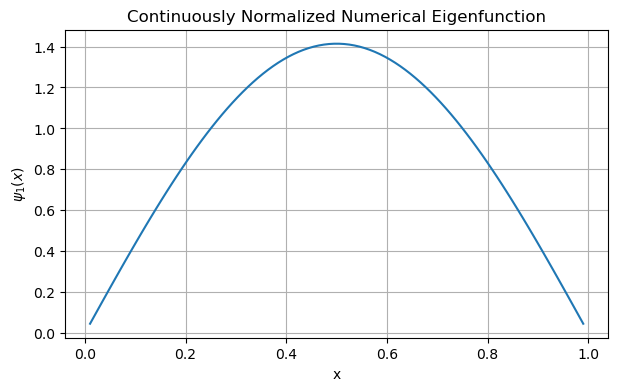

In [ ]:
state_index = 0  # n=1

plt.figure(figsize=(7, 4))
plt.plot(piab1d.x_interior, psi_cont[:, state_index])

plt.xlabel("x")
plt.ylabel(r"$\psi_1(x)$")
plt.title("Continuously Normalized Numerical Eigenfunction")
plt.grid(True)
plt.show()

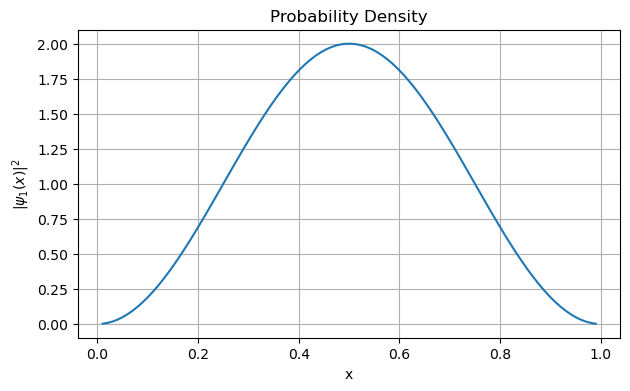

Total probability = 1.0000000000


In [ ]:
state_index = 0  # n=1

prob_density = np.abs(psi_cont[:, state_index])**2

plt.figure(figsize=(7, 4))
plt.plot(piab1d.x_interior, prob_density)

plt.xlabel("x")
plt.ylabel(r"$|\psi_1(x)|^2$")
plt.title("Probability Density")
plt.grid(True)
plt.show()

probability_check = np.sum(prob_density) * piab1d.dx
print(f"Total probability = {probability_check:.10f}")

In [ ]:
def project_onto_eigenbasis(
    phi_array: np.ndarray,
    psi_basis: np.ndarray,
    dx: float,
) -> np.ndarray:
    """
    Project a continuous-normalized wavefunction phi_array
    onto a continuous-normalized eigenbasis psi_basis.

    Parameters
    ----------
    phi_array:
        Array representing phi(x_i).

    psi_basis:
        Matrix whose columns are eigenfunctions psi_n(x_i),
        normalized so that sum_i |psi_n(x_i)|^2 dx = 1.

    dx:
        Grid spacing.

    Returns
    -------
    c_array:
        Expansion coefficients c_n = <psi_n | phi>.
    """
    c_array = psi_basis.conj().T @ phi_array * dx
    return c_array

In [ ]:
def gaussian_state(
    x_array: np.ndarray,
    x0: float,
    sigma: float,
    k0: float = 0.0,
) -> np.ndarray:
    """
    Build a Gaussian wave packet on the grid.

    The factor exp(i k0 x) adds average momentum.
    """
    envelope = np.exp(-((x_array - x0)**2) / (2.0 * sigma**2))
    phase = np.exp(1j * k0 * x_array)

    phi = envelope * phase

    return phi

In [ ]:
def normalize_wavefunction(
    phi_array: np.ndarray,
    dx: float,
) -> np.ndarray:
    """
    Normalize a grid wavefunction so that sum_i |phi_i|^2 dx = 1.
    """
    norm = np.sqrt(np.sum(np.abs(phi_array)**2) * dx)

    if norm == 0:
        raise ValueError("Cannot normalize the zero wavefunction.")

    return phi_array / norm

In [ ]:
x = piab1d.x_interior
dx = piab1d.dx

phi = gaussian_state(
    x_array=x,
    x0=0.5,
    sigma=0.10,
    k0=0.0,
)

phi = normalize_wavefunction(phi, dx)

probability_check = np.sum(np.abs(phi)**2) * dx
print(f"norm of phi = {probability_check:.10f}")

norm of phi = 1.0000000000


In [ ]:
# Use the continuous-normalized eigenfunctions
psi_basis = piab1d.eigvec/np.sqrt(piab1d.dx)

c_array = project_onto_eigenbasis(
    phi_array=phi,
    psi_basis=psi_basis,
    dx=dx,
)

probabilities = np.abs(c_array)**2
print(probabilities)
print(probabilities.shape)
print(f"sum_n |c_n|^2 = {np.sum(probabilities):.10f}")

[6.42350121e-01 3.90452890e-26 2.91653016e-01 2.20385238e-27
 6.01252227e-02 1.21098993e-30 5.62780163e-03 1.75112538e-28
 2.39183386e-04 1.00529100e-28 4.61430872e-06 5.91116988e-29
 4.05274157e-08 1.42062291e-29 1.54975941e-10 2.26307714e-30
 5.97871796e-13 7.44740803e-32 4.64606521e-14 1.96835442e-30
 5.08776246e-14 9.89155833e-33 4.74948639e-14 3.14919677e-31
 4.39528736e-14 1.23049289e-31 4.03427985e-14 5.18059163e-32
 3.68130234e-14 1.52215919e-32 3.34503638e-14 5.26142221e-32
 3.03010501e-14 2.52848401e-32 2.73848275e-14 3.21938096e-34
 2.47048364e-14 1.47136160e-31 2.22542680e-14 3.77161774e-33
 2.00207560e-14 6.10959141e-32 1.79891805e-14 1.19926195e-33
 1.61434345e-14 1.55409692e-32 1.44674876e-14 1.77247947e-34
 1.29460029e-14 5.73089433e-33 1.15646663e-14 2.26840068e-33
 1.03103335e-14 1.95397895e-32 9.17106866e-15 5.23737410e-32
 8.13611498e-15 7.72196230e-32 7.19583153e-15 4.54342472e-32
 6.34160988e-15 1.57648272e-32 5.56578484e-15 1.23518579e-34
 4.86154537e-15 8.730915

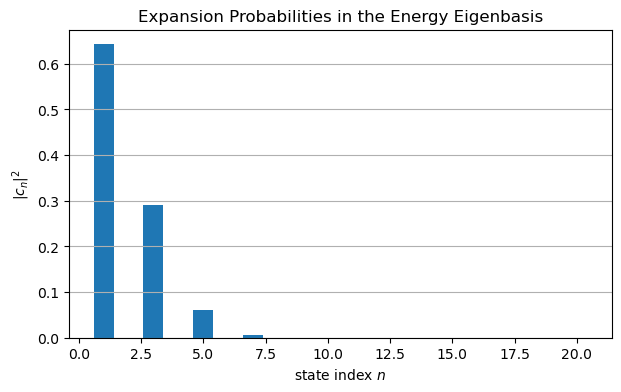

sum of plotted probabilities = 1.0000000000
sum over all computed probabilities = 1.0000000000


In [ ]:
probabilities = np.abs(c_array)**2

num_plot = 20
n_array = np.arange(1, num_plot + 1)

plt.figure(figsize=(7, 4))
plt.bar(n_array, probabilities[:num_plot])

plt.xlabel("state index $n$")
plt.ylabel(r"$|c_n|^2$")
plt.title("Expansion Probabilities in the Energy Eigenbasis")
plt.grid(True, axis="y")

plt.show()

print(f"sum of plotted probabilities = {np.sum(probabilities[:num_plot]):.10f}")
print(f"sum over all computed probabilities = {np.sum(probabilities):.10f}")

In [ ]:
kB = 1.0
T = 1.0
beta = 1.0 / (kB * T)

E = piab1d.eigval

boltzmann_weights = np.exp(-beta * E)
Z = np.sum(boltzmann_weights)

P_thermal = boltzmann_weights / Z

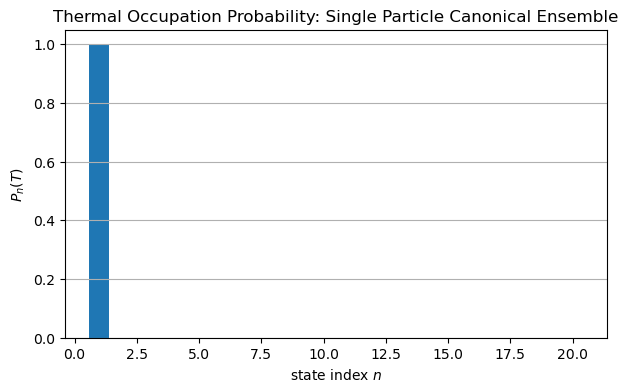

In [ ]:
num_plot = 20
n_array = np.arange(1, num_plot + 1)

plt.figure(figsize=(7, 4))
plt.bar(n_array, P_thermal[:num_plot])

plt.xlabel("state index $n$")
plt.ylabel(r"$P_n(T)$")
plt.title("Thermal Occupation Probability: Single Particle Canonical Ensemble")
plt.grid(True, axis="y")
plt.show()

---
© 2026 Eugene Joseph M. Ragasa.

This work is licensed under the Creative Commons Attribution-NonCommercial 4.0 International License (CC BY-NC 4.0), unless otherwise noted.

You may copy, redistribute, and modify this material for noncommercial academic or instructional purposes, provided that appropriate attribution is given.

Commercial use, including paid courseware, commercial training, textbook reproduction, platform monetization, or resale, requires a separate written license from the author.

Third-party figures, excerpts, datasets, and other credited materials remain under their respective copyrights and licenses.